检测到的峰位： [ 251.502  309.094  358.812  433.984  488.945  565.197  640.649  727.092
  826.433  851.919  891.123 1017.6   1067.11  1112.92  1181.61  1220.09
 1296.39  1327.75  1380.41  1478.27  1533.18  1562.56  1600.15  1652.
 1691.15  1715.75  1737.2   1774.82  1804.16  1825.32  1884.42  1920.21
 1942.97  1981.39 ]
检测到的峰强度： [ 446.7207559   785.65475189  195.09663837  622.42422308  291.94041225
  770.07207414  833.28818906  857.95393118  672.42345799  609.76590468
  588.70756034  835.80491453  639.2795018   460.55756507 1098.96710622
 1085.27688681  531.5505261   579.23672451  408.31344038  678.6871422
  379.91487732  254.63660916  378.97998701  259.12929716    6.04662296
   55.24319608   68.52912149  150.04036516  116.52029118  115.41768833
   47.96016544  258.10781739  218.51924062   63.11360526]
峰 1: 峰位=261.50, 峰高=374.87, 峰宽=588.71, 峰面积=139899.06
峰 2: 峰位=319.09, 峰高=450.02, 峰宽=588.71, 峰面积=192216.64
峰 3: 峰位=368.81, 峰高=393.27, 峰宽=399.78, 峰面积=140321.52
峰 4: 峰位=443.98, 峰高=499.27, 峰宽=588.71,

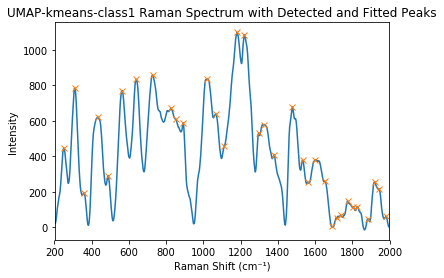

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.optimize import curve_fit
from scipy.integrate import quad
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# 定义高斯函数
def gaussian(x, a, b, c):
    return a * np.exp(-(x - b)**2 / (2 * c**2))



# 加载数据
data_files = ["C:/Users/86183/BS/BS/labels_cluster/labels_umap_kmeans_average.csv"]
# data_files=["average_two.csv"]
data = pd.read_csv(data_files[0], sep=',', header=None)  # 以第一个文件为例
x_data = data.iloc[0].values  # 波数
y_data1 = data.iloc[1].values  # 强度


# 峰检测
peaks, properties = find_peaks(y_data1, height=0.05, distance=20, prominence=0.02)
print("检测到的峰位：", x_data[peaks])
print("检测到的峰强度：", properties['peak_heights'])

# 定义多高斯函数
def multi_gaussian(x, *params):
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        a, b, c = params[i:i+3]
        y += gaussian(x, a, b, c)
    return y

# 高斯拟合
fitted_peaks = []
for idx, peak in enumerate(peaks):  # 使用 enumerate 获取峰的索引和位置
    # 动态调整拟合范围
    fit_range = int(20 + 10 * np.sqrt(properties['peak_heights'][idx]))  # 根据峰高动态调整拟合范围
    x_fit = x_data[max(0, peak - fit_range):min(len(x_data), peak + fit_range)]
    y_fit = y_data1[max(0, peak - fit_range):min(len(y_data1), peak + fit_range)]

    # 初始参数优化
    initial_guess = [
        properties['peak_heights'][idx],  # 峰高
        x_data[peak],  # 峰位
        5  # 初始峰宽（根据实际情况调整）
    ]
    
    # 设置参数的上下限
    lower_bounds = [0, x_data[peak] - 10, 1]  # 峰高下限、峰位下限、峰宽下限
    upper_bounds = [np.inf, x_data[peak] + 10, 250]  # 峰高上限、峰位上限、峰宽上限
    
    try:
        popt, _ = curve_fit(
            gaussian, 
            x_fit, 
            y_fit, 
            p0=initial_guess, 
            bounds=(lower_bounds, upper_bounds), 
            maxfev=5000  # 增加迭代次数
        )
        fitted_peaks.append(popt)
    except RuntimeError as e:
        print(f"拟合失败，峰位置：{x_data[peak]}，错误信息：{e}")
        continue

# 计算峰宽（FWHM）、峰面积和峰强度
peak_features = []
for i, params in enumerate(fitted_peaks):
    a, b, c = params
    fwhm = 2 * np.sqrt(2 * np.log(2)) * c  # 半峰全宽（FWHM）
    
    # 高斯拟合积分法计算峰面积
    peak_area, _ = quad(gaussian, min(x_data), max(x_data), args=(a, b, c))
    
    # 拟合峰高法计算峰强度
    peak_height = a  # 峰高即为高斯函数的幅值 a
    
    peak_features.append([b, peak_height, fwhm, peak_area])
    print(f"峰 {i+1}: 峰位={b:.2f}, 峰高={peak_height:.2f}, 峰宽={fwhm:.2f}, 峰面积={peak_area:.2f}")

# 将特征矩阵存储为 DataFrame
feature_matrix = pd.DataFrame(peak_features, columns=['Peak Position', 'Peak Height', 'FWHM', 'Peak Area'])

# 输出特征矩阵
print("\n特征矩阵：")
print(feature_matrix)

# 可视化
# plt.plot(x_data, y_smooth, label='Smoothed Spectrum')
plt.plot(x_data, y_data1, label='Baseline Corrected Spectrum')
plt.plot(x_data[peaks], y_data1[peaks], "x", label='Detected Peaks')
# for params in fitted_peaks:
#     plt.plot(x_data, gaussian(x_data, *params), '--', label=f'Fitted Peak at {params[1]:.2f}')
#plt.legend()
plt.xlabel('Raman Shift (cm⁻¹)')
plt.ylabel('Intensity')
plt.title('UMAP-kmeans-class1 Raman Spectrum with Detected and Fitted Peaks')
plt.xlim(min(x_data), max(x_data))
plt.show()

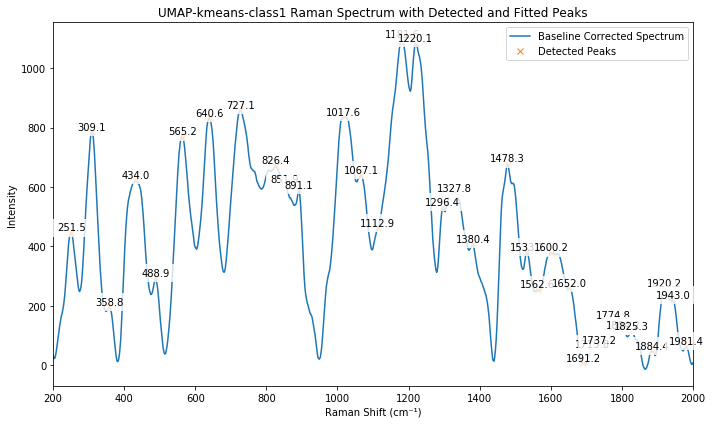

In [3]:
# 可视化
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data1, label='Baseline Corrected Spectrum')
plt.plot(x_data[peaks], y_data1[peaks], "x", label='Detected Peaks')

# 在每个峰的位置添加文本标签
for peak_x, peak_y in zip(x_data[peaks], y_data1[peaks]):
    plt.text(peak_x, peak_y, f'{peak_x:.1f}', 
             ha='center', va='bottom', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.xlabel('Raman Shift (cm⁻¹)')
plt.ylabel('Intensity')
plt.title('UMAP-kmeans-class1 Raman Spectrum with Detected and Fitted Peaks')
plt.xlim(min(x_data), max(x_data))
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd

# 创建包含峰位和峰高的DataFrame
peaks_df = pd.DataFrame({
    '峰位(cm⁻¹)': x_data[peaks],
})

# 保存为CSV文件（不包含索引列）
peaks_df.to_csv('peaks1.csv', index=False, encoding='utf-8-sig')


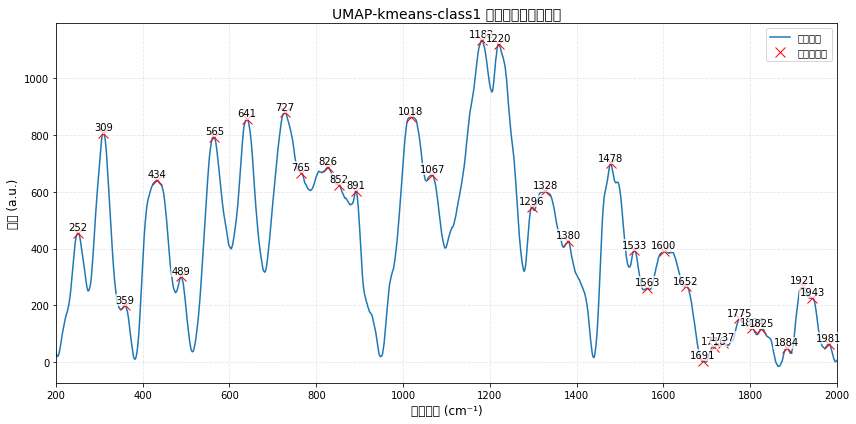

In [16]:
# 可视化
plt.figure(figsize=(12, 6))
plt.plot(x_data, y_data1, label='原始光谱')
plt.plot(x_data[peaks], y_data1[peaks], "x", color='red', markersize=10, label='检测到的峰')

# 在每个峰上标注拉曼位移值
for peak_pos in x_data[peaks]:
    # 找到最接近的y值
    idx = np.abs(x_data - peak_pos).argmin()
    y_val = y_data1[idx]
    
    # 添加文本标注
    plt.text(peak_pos, y_val# 可视化
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data1, label='Baseline Corrected Spectrum')
plt.plot(x_data[peaks], y_data1[peaks], "x", label='Detected Peaks')

# 在每个峰的位置添加文本标签
for peak_x, peak_y in zip(x_data[peaks], y_data1[peaks]):
    plt.text(peak_x, peak_y, f'{peak_x:.1f}', 
             ha='center', va='bottom', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.xlabel('Raman Shift (cm⁻¹)')
plt.ylabel('Intensity')
plt.title('UMAP-kmeans-class1 Raman Spectrum with Detected and Fitted Peaks')
plt.xlim(min(x_data), max(x_data))
plt.legend()
plt.tight_layout()
plt.show()
,  # 位置稍微上移一点避免重叠
             f'{int(round(peak_pos))}',  # 显示为整数
             horizontalalignment='center',
             verticalalignment='bottom',
             fontsize=10,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.xlabel('拉曼位移 (cm⁻¹)', fontsize=12)
plt.ylabel('强度 (a.u.)', fontsize=12)
plt.title('UMAP-kmeans-class1 拉曼光谱及峰位标注', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.xlim(min(x_data), max(x_data))
plt.tight_layout()
plt.show()


检测到的峰位： [ 251.502  310.343  358.812  433.984  487.728  562.789  633.497  727.092
  779.858  826.433  853.074  889.973  926.678 1035.65  1067.11  1181.61
 1220.09  1295.31  1316.96  1381.48  1496.27  1533.18  1563.61  1597.02
 1618.86  1650.97  1714.72  1737.2   1774.82  1804.16  1824.32  1883.42
 1921.2   1941.99  1981.39 ]
检测到的峰强度： [ 965.98001006 1765.26355865  420.82833319 1412.28956922  686.19741385
 1787.09375326 1787.23860673 1648.05226175 1140.79839405 1254.21155855
 1150.82947712 1137.06281492  312.87981925 1979.38780216 1489.84451433
 2476.12898997 2480.14118115 1295.73833464 1347.25564154  970.23825897
 1322.5516884   760.51859757  475.03072143  803.48837326  756.432641
  696.45464775   76.99638935   96.84675188  299.44890002  238.86113361
  227.86173369   82.66845768  548.96308545  466.87818037  112.0298715 ]
峰 1: 峰位=261.50, 峰高=1016.47, 峰宽=588.71, 峰面积=379338.57
峰 2: 峰位=320.34, 峰高=1109.73, 峰宽=588.71, 峰面积=475232.25
峰 3: 峰位=368.81, 峰高=935.98, 峰宽=588.71, 峰面积=439261.61
峰 4: 峰位=443

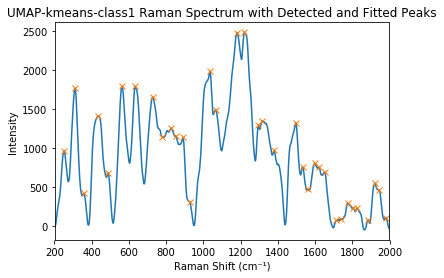

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.optimize import curve_fit
from scipy.integrate import quad
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# 定义高斯函数
def gaussian(x, a, b, c):
    return a * np.exp(-(x - b)**2 / (2 * c**2))



# 加载数据
data_files = ["C:/Users/86183/BS/BS/labels_cluster/labels_umap_kmeans_average.csv"]
# data_files=["average_two.csv"]
data = pd.read_csv(data_files[0], sep=',', header=None)  # 以第一个文件为例
x_data = data.iloc[0].values  # 波数
y_data1 = data.iloc[2].values  # 强度


# 峰检测
peaks, properties = find_peaks(y_data1, height=0.05, distance=20, prominence=0.02)
print("检测到的峰位：", x_data[peaks])
print("检测到的峰强度：", properties['peak_heights'])

# 定义多高斯函数
def multi_gaussian(x, *params):
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        a, b, c = params[i:i+3]
        y += gaussian(x, a, b, c)
    return y

# 高斯拟合
fitted_peaks = []
for idx, peak in enumerate(peaks):  # 使用 enumerate 获取峰的索引和位置
    # 动态调整拟合范围
    fit_range = int(20 + 10 * np.sqrt(properties['peak_heights'][idx]))  # 根据峰高动态调整拟合范围
    x_fit = x_data[max(0, peak - fit_range):min(len(x_data), peak + fit_range)]
    y_fit = y_data1[max(0, peak - fit_range):min(len(y_data1), peak + fit_range)]

    # 初始参数优化
    initial_guess = [
        properties['peak_heights'][idx],  # 峰高
        x_data[peak],  # 峰位
        5  # 初始峰宽（根据实际情况调整）
    ]
    
    # 设置参数的上下限
    lower_bounds = [0, x_data[peak] - 10, 1]  # 峰高下限、峰位下限、峰宽下限
    upper_bounds = [np.inf, x_data[peak] + 10, 250]  # 峰高上限、峰位上限、峰宽上限
    
    try:
        popt, _ = curve_fit(
            gaussian, 
            x_fit, 
            y_fit, 
            p0=initial_guess, 
            bounds=(lower_bounds, upper_bounds), 
            maxfev=5000  # 增加迭代次数
        )
        fitted_peaks.append(popt)
    except RuntimeError as e:
        print(f"拟合失败，峰位置：{x_data[peak]}，错误信息：{e}")
        continue

# 计算峰宽（FWHM）、峰面积和峰强度
peak_features = []
for i, params in enumerate(fitted_peaks):
    a, b, c = params
    fwhm = 2 * np.sqrt(2 * np.log(2)) * c  # 半峰全宽（FWHM）
    
    # 高斯拟合积分法计算峰面积
    peak_area, _ = quad(gaussian, min(x_data), max(x_data), args=(a, b, c))
    
    # 拟合峰高法计算峰强度
    peak_height = a  # 峰高即为高斯函数的幅值 a
    
    peak_features.append([b, peak_height, fwhm, peak_area])
    print(f"峰 {i+1}: 峰位={b:.2f}, 峰高={peak_height:.2f}, 峰宽={fwhm:.2f}, 峰面积={peak_area:.2f}")

# 将特征矩阵存储为 DataFrame
feature_matrix = pd.DataFrame(peak_features, columns=['Peak Position', 'Peak Height', 'FWHM', 'Peak Area'])

# 输出特征矩阵
print("\n特征矩阵：")
print(feature_matrix)

# 可视化
# plt.plot(x_data, y_smooth, label='Smoothed Spectrum')
plt.plot(x_data, y_data1, label='Baseline Corrected Spectrum')
plt.plot(x_data[peaks], y_data1[peaks], "x", label='Detected Peaks')
# for params in fitted_peaks:
#     plt.plot(x_data, gaussian(x_data, *params), '--', label=f'Fitted Peak at {params[1]:.2f}')
#plt.legend()
plt.xlabel('Raman Shift (cm⁻¹)')
plt.ylabel('Intensity')
plt.title('UMAP-kmeans-class1 Raman Spectrum with Detected and Fitted Peaks')
plt.xlim(min(x_data), max(x_data))
plt.show()

In [2]:
data

,0,1,2,3,4,5,6,7,8,9,...,1607,1608,1609,1610,1611,1612,1613,1614,1615,1616
0,201.053000,202.319000,203.584000,204.850000,206.115000,207.378000,208.643000,209.907000,211.171000,212.435000,...,1990.230000,1991.210000,1992.190000,1993.170000,1994.150000,1995.130000,1996.110000,1997.090000,1998.070000,1999.050000
1,29.671449,23.159265,20.522180,21.346206,25.217354,31.721636,40.445064,50.973649,62.893403,75.790338,...,25.114029,19.394052,14.167718,9.617481,5.925794,3.275112,1.847889,1.826577,3.393630,6.731503
2,53.912376,28.469930,14.405463,10.479641,15.453130,28.086594,47.140701,71.376114,99.553500,130.433525,...,30.976227,19.760190,8.970767,-1.209301,-10.597278,-19.010423,-26.265999,-32.181267,-36.573489,-39.259927


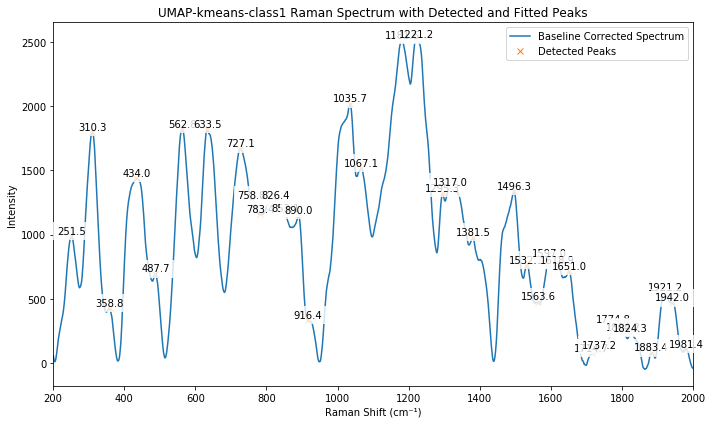

In [11]:
# 可视化
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data2, label='Baseline Corrected Spectrum')
plt.plot(x_data[peaks], y_data2[peaks], "x", label='Detected Peaks')

# 在每个峰的位置添加文本标签
for peak_x, peak_y in zip(x_data[peaks], y_data2[peaks]):
    plt.text(peak_x, peak_y, f'{peak_x:.1f}', 
             ha='center', va='bottom', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.xlabel('Raman Shift (cm⁻¹)')
plt.ylabel('Intensity')
plt.title('UMAP-kmeans-class1 Raman Spectrum with Detected and Fitted Peaks')
plt.xlim(min(x_data), max(x_data))
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
x_data.shape

(1617,)